<a href="https://colab.research.google.com/github/Chiya18/oralCancerDetection_CNN/blob/main/OralCancerDetection_Cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Conv2D,Dense,Dropout,BatchNormalization,Flatten,MaxPool2D,MaxPooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau,ModelCheckpoint
from tensorflow.keras.regularizers import l2

# Load data

In [ ]:
# Load data
from PIL import UnidentifiedImageError

def load_data(folder_path):
    images = []
    labels = []
    allowed_extensions = ['.jpg', '.jpeg', '.png', '.gif']  # Add other supported extensions if needed
    for label, category in enumerate(['CANCER', 'NON CANCER']):
        category_folder = os.path.join(folder_path, category)
        for file_name in os.listdir(category_folder):
            if os.path.splitext(file_name)[1].lower() in allowed_extensions:
                image_path = os.path.join(category_folder, file_name)
                try:
                    image = load_img(image_path, target_size=(128, 128))
                    image_array = img_to_array(image)
                    images.append(image_array)
                    labels.append(label)
                except UnidentifiedImageError:
                    print(f"Skipping file: {image_path} - UnidentifiedImageError")
            else:
                print(f"Skipping file: {file_name} - Invalid file type")
    return np.array(images), np.array(labels)

folder_path = "/content/drive/MyDrive/archive/Oral cancer Dataset 2.0/OC Dataset kaggle new"
images, labels = load_data(folder_path)

/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Skipping file: /content/drive/MyDrive/archive/Oral cancer Dataset 2.0/OC Dataset kaggle new/CANCER/101.jpeg - UnidentifiedImageError
Skipping file: /content/drive/MyDrive/archive/Oral cancer Dataset 2.0/OC Dataset kaggle new/CANCER/200.jpeg - UnidentifiedImageError
Skipping file: /content/drive/MyDrive/archive/Oral cancer Dataset 2.0/OC Dataset kaggle new/CANCER/273.jpeg - UnidentifiedImageError
Skipping file: /content/drive/MyDrive/archive/Oral cancer Dataset 2.0/OC Dataset kaggle new/CANCER/317.jpeg - UnidentifiedImageError
Skipping file: /content/drive/MyDrive/archive/Oral cancer Dataset 2.0/OC Dataset kaggle new/CANCER/328.jpeg - UnidentifiedImageError
Skipping file: /content/drive/MyDrive/archive/Oral cancer Dataset 2.0/OC Dataset kaggle new/CANCER/407.jpeg - UnidentifiedImageError
Skipping file: /content/drive/MyDrive/archive/Oral cancer Dataset 2.0/OC Dataset kaggle new/CANCER/450.jpeg - UnidentifiedImageError
Skipping file: /content/drive/MyDrive/archive/Oral cancer Dataset 2.0

In [ ]:
images[0]

array([[[109., 100.,  95.],
        [106.,  97.,  92.],
        [124., 109., 106.],
        ...,
        [209., 200., 193.],
        [172., 163., 156.],
        [199., 195., 184.]],

       [[ 93.,  84.,  79.],
        [102.,  88.,  85.],
        [115.,  94.,  93.],
        ...,
        [199., 190., 185.],
        [166., 155., 151.],
        [194., 187., 179.]],

       [[ 96.,  82.,  79.],
        [110.,  92.,  90.],
        [117.,  88.,  90.],
        ...,
        [166., 152., 152.],
        [170., 156., 155.],
        [195., 184., 182.]],

       ...,

       [[  1.,  40.,  69.],
        [  0.,  39.,  68.],
        [ 12.,  48.,  84.],
        ...,
        [ 59.,  72.,  78.],
        [ 55.,  69.,  72.],
        [ 65.,  73.,  75.]],

       [[  5.,  43.,  79.],
        [  5.,  41.,  75.],
        [  1.,  37.,  73.],
        ...,
        [ 51.,  62.,  66.],
        [ 48.,  58.,  60.],
        [ 65.,  71.,  71.]],

       [[ 21.,  58.,  85.],
        [ 20.,  56.,  82.],
        [ 12.,  

In [ ]:
labels[0]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42, shuffle=True)

# Define and compile the model
model = Sequential()

model.add(Conv2D(filters=64, kernel_size=(3, 3), input_shape=(128, 128, 3), activation='relu', kernel_regularizer=l2(0.01)))
model.add(MaxPool2D(pool_size=(2, 2)))

model.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu', kernel_regularizer=l2(0.01)))
model.add(MaxPool2D(pool_size=(2, 2)))

model.add(Conv2D(filters=256, kernel_size=(3, 3), activation='relu', kernel_regularizer=l2(0.01)))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(BatchNormalization())

model.add(Conv2D(filters=512, kernel_size=(3, 3), activation='relu', kernel_regularizer=l2(0.01)))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.6830 - loss: 8.3595 - precision: 0.2845 - recall: 0.5058
Epoch 1: val_accuracy improved from -inf to 0.22131, saving model to /kaggle/working/best_model.keras
16/16 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.6858 - loss: 8.3990 - precision: 0.2880 - recall: 0.5024 - val_accuracy: 0.2213 - val_loss: 327.4358 - val_precision: 0.2149 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8140 - loss: 8.3126 - precision: 0.4531 - recall: 0.5837
Epoch 2: val_accuracy did not improve from 0.22131
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.8149 - loss: 8.3234 - precision: 0.4594 - recall: 0.5812 - val_accuracy: 0.2213 - val_loss: 108.8565 - val_precision: 0.2149 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/50
15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8485 - loss: 6.5450 - precision: 0.5903 - recall: 0.7369
Epoch 3: val_accuracy did not imp

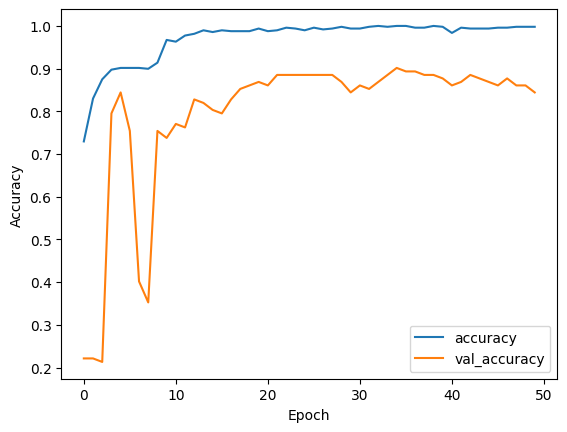

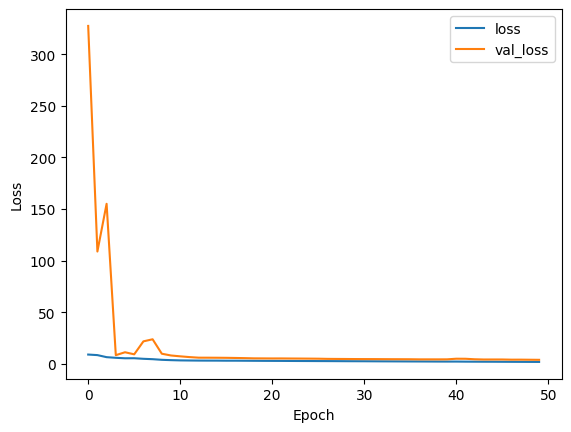

In [ ]:
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(BatchNormalization())
model.add(Dropout(0.4))

model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy',metrics=['accuracy',tf.keras.metrics.Precision(),tf.keras.metrics.Recall()],optimizer='adam')

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, min_lr=0.00001)
checkpoint_filepath = '/kaggle/working/best_model.keras'
checkpoint = ModelCheckpoint(
    checkpoint_filepath,
    monitor='val_accuracy',  # Save the model based on validation accuracy
    save_best_only=True,      # Only save the best model
    mode='max',               # Save the model when the monitored quantity is maximized
    verbose=1
)

# Train the model
history = model.fit(
    x= X_train,
    y= y_train,
    epochs=50,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, reduce_lr,checkpoint]
)
# Plot accuracy and loss
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()

In [ ]:
# prompt: now give me file upload option and predict

from google.colab import files
import io
import numpy as np
from PIL import Image

uploaded = files.upload()

for fn in uploaded.keys():
  try:
    img = Image.open(io.BytesIO(uploaded[fn]))
    img = img.resize((128, 128)) # Resize the image to match the input shape of the model
    img_array = np.array(img) / 255.0 # Normalize the image
    img_array = np.expand_dims(img_array, axis=0) # Add a batch dimension

    prediction = model.predict(img_array)
    print(f"Prediction for {fn}: {prediction}")
    if prediction[0][0] > 0.5:
        print("Cancer")
    else:
        print("Non-Cancer")
  except Exception as e:
      print(f"Error processing {fn}: {e}")

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Step 1: Predict on Test Data
y_pred_probs = model.predict(X_test)      # Get probabilities
y_pred = (y_pred_probs > 0.5).astype(int) # Convert to 0 or 1 since it's binary classification

# Step 2: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Step 3: Display Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Cancer', 'Cancer'])
disp.plot(cmap=plt.cm.Blues)
plt.show()

# Step 4 (Optional): Classification Report (Precision, Recall, F1-score)
print(classification_report(y_test, y_pred, target_names=['Non-Cancer', 'Cancer']))

